In [94]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import pickle


In [95]:
df = pd.read_csv('preprocessed_demand_forecasting_data.csv')

In [96]:
df.head()

,Unnamed: 0,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,...,Competitor Pricing,Seasonality,Epidemic,Demand,Year,Month,Day,Weekday,Discounted Price,Sell Through Rate
0,0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,...,85.73,Winter,0,115,2022,1,1,Saturday,69.084,0.523077
1,1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,...,92.02,Winter,0,229,2022,1,1,Saturday,68.136,1.000000
2,2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,...,60.08,Winter,0,157,2022,1,1,Saturday,56.646,0.461538
3,3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,...,85.19,Winter,0,52,2022,1,1,Saturday,78.867,0.323741
4,4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,...,51.63,Winter,0,59,2022,1,1,Saturday,54.410,0.427632


In [97]:
features = ['Price',
            'Discount',
            'Inventory Level',
            'Promotion',
            'Competitor Pricing',
            'Category',
            ]

In [98]:
df[features]

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,Electronics
1,80.16,15,117,1,92.02,Clothing
2,62.94,10,247,1,60.08,Clothing
3,87.63,10,139,0,85.19,Electronics
4,54.41,0,152,0,51.63,Groceries
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,Toys
75996,42.92,5,137,0,40.73,Toys
75997,17.81,10,197,0,19.41,Clothing
75998,151.72,0,125,0,143.71,Furniture


In [99]:
X = df[features].copy()

In [100]:
Y = df['Demand']

In [101]:
label_encoders = {}

categorical_cols = X.select_dtypes(include='object').columns

In [102]:
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [103]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.2)

In [104]:
X

,Price,Discount,Inventory Level,Promotion,Competitor Pricing,Category
0,72.72,5,195,0,85.73,1
1,80.16,15,117,1,92.02,0
2,62.94,10,247,1,60.08,0
3,87.63,10,139,0,85.19,1
4,54.41,0,152,0,51.63,3
...,...,...,...,...,...,...
75995,29.80,5,233,0,32.23,4
75996,42.92,5,137,0,40.73,4
75997,17.81,10,197,0,19.41,0
75998,151.72,0,125,0,143.71,2


In [105]:
xgb = XGBRegressor(objective= 'reg:squarederror', n_jobs = -1)

In [106]:
param_dict = {
    'n_estimators':[200, 300, 500],
    'max_depth':[3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

In [107]:
random_search = RandomizedSearchCV(
    estimator= xgb,
    param_distributions= param_dict,
    n_iter = 25,
    scoring = 'neg_mean_absolute_error',
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

In [108]:
random_search.fit(X_train, Y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1]},
                   scoring='neg_mean_absolute_error', verbose=1)

In [109]:
random_search.best_params_

{'subsample': 1,
 'n_estimators': 200,
 'min_child_weight': 1,
 'max_depth': 8,
 'learning_rate': 0.05,
 'colsample_bytree': 0.7}

In [110]:
best_model = random_search.best_estimator_

In [111]:
Y_pred = best_model.predict(X_test)

In [112]:
np.sqrt(mean_squared_error(Y_test, Y_pred))

35.77922176293019

In [113]:
best_model.feature_importances_

array([0.10295554, 0.06162392, 0.02421897, 0.37826958, 0.03602363,
       0.39690834], dtype=float32)

In [114]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

In [115]:
feature_importance

Category              0.396908
Promotion             0.378270
Price                 0.102956
Discount              0.061624
Competitor Pricing    0.036024
Inventory Level       0.024219
dtype: float32

<Axes: >

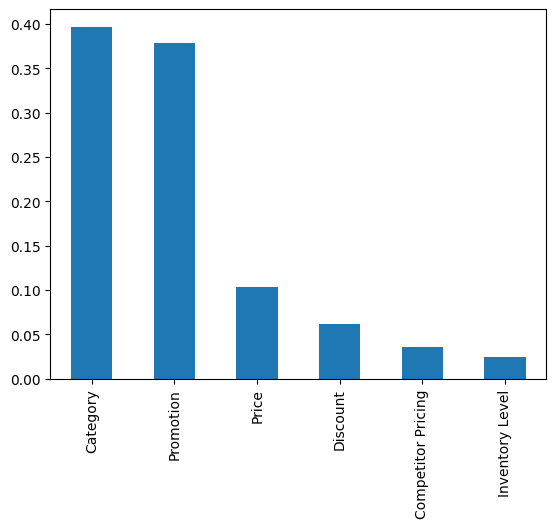

In [116]:
feature_importance.plot(kind='bar')

In [117]:
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

In [118]:
with open('xgboost_demand_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)